In [1]:
from google.colab import files
uploaded = files.upload()

Saving product_info.csv to product_info.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("product_info.csv")
df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,price_usd,primary_category
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,35.0,Fragrance
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,195.0,Fragrance
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,195.0,Fragrance
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,195.0,Fragrance
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,195.0,Fragrance


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (5504, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5504 entries, 0 to 5503
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        5504 non-null   object 
 1   product_name      5504 non-null   object 
 2   brand_id          5504 non-null   int64  
 3   brand_name        5504 non-null   object 
 4   loves_count       5504 non-null   int64  
 5   rating            5328 non-null   float64
 6   reviews           5328 non-null   float64
 7   price_usd         5504 non-null   float64
 8   primary_category  5504 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 387.1+ KB


In [5]:
df.describe(include="all").T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,5504,5504,P502897,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,5504,5473,Mini Perfume Oil Set,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand_id,5504.0,NaN,NaN,NaN,5440.6121,1846.663001,1063.0,5644.0,6183.0,6335.0,8017.0
brand_name,5504,202,CLINIQUE,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loves_count,5504.0,NaN,NaN,NaN,27673.64008,63549.493335,0.0,3618.5,9689.0,25520.75,1153594.0
rating,5328.0,NaN,NaN,NaN,4.189618,0.519381,1.0,3.970225,4.2857,4.527225,5.0
reviews,5328.0,NaN,NaN,NaN,434.826014,1097.096037,1.0,27.0,115.0,390.25,21281.0
price_usd,5504.0,NaN,NaN,NaN,53.007518,48.221667,4.0,26.0,36.0,60.0,465.0
primary_category,5504,8,Makeup,1505,NaN,NaN,NaN,NaN,NaN,NaN,NaN


MISSING VALUES

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)
pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(20)

,missing,missing_%
reviews,176,3.197674
rating,176,3.197674
product_id,0,0.000000
product_name,0,0.000000
brand_id,0,0.000000
loves_count,0,0.000000
brand_name,0,0.000000
price_usd,0,0.000000
primary_category,0,0.000000


MISSING VALUES HEATMAP

/tmp/ipykernel_4251/2373248925.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')


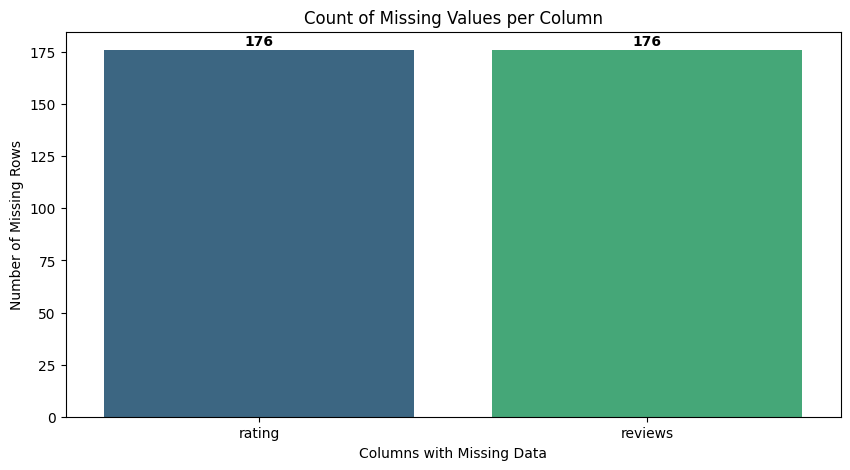

In [7]:
# Calculate missing values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0] # Only show columns with missing values

if not missing_data.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')

    plt.title('Count of Missing Values per Column')
    plt.ylabel('Number of Missing Rows')
    plt.xlabel('Columns with Missing Data')

    # Adding the count labels on top of the bars
    for i, val in enumerate(missing_data.values):
        plt.text(i, val + 2, str(val), ha='center', fontweight='bold')

    plt.show()
else:
    print("No missing values found in the dataset!")

LET'S VISUALIZE THE DISTRIBUTION OF PRODUCT_NAME

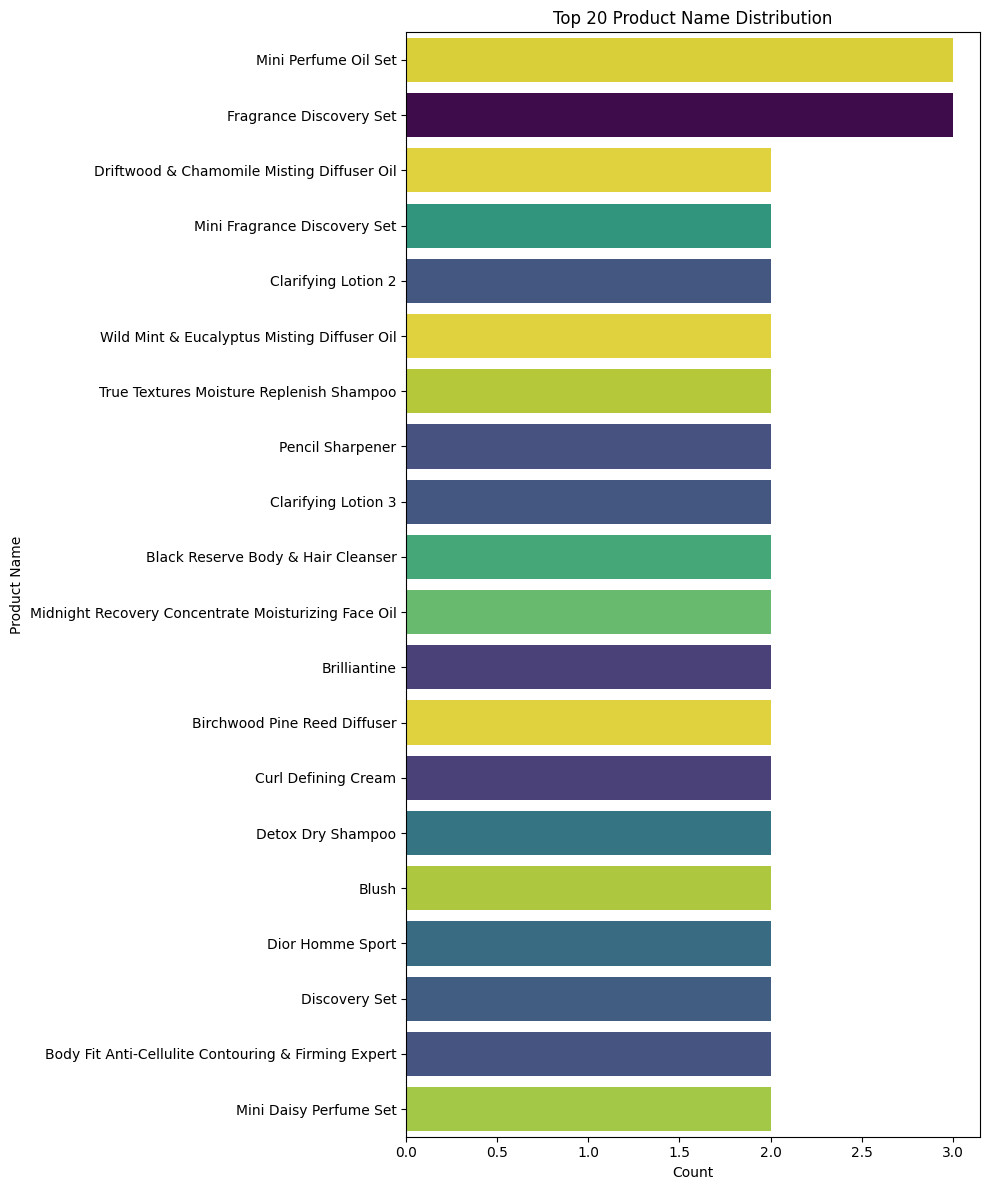

In [8]:
plt.figure(figsize=(10, 12))

sns.countplot(
    data=df,
    y='product_name',
    order=df['product_name'].value_counts().iloc[:20].index,
    palette='viridis',
    hue='product_name',
    legend=False
)

plt.title('Top 20 Product Name Distribution')
plt.xlabel('Count')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

VISUALIZING THE DISTRIBUTION OF BRAND NAME

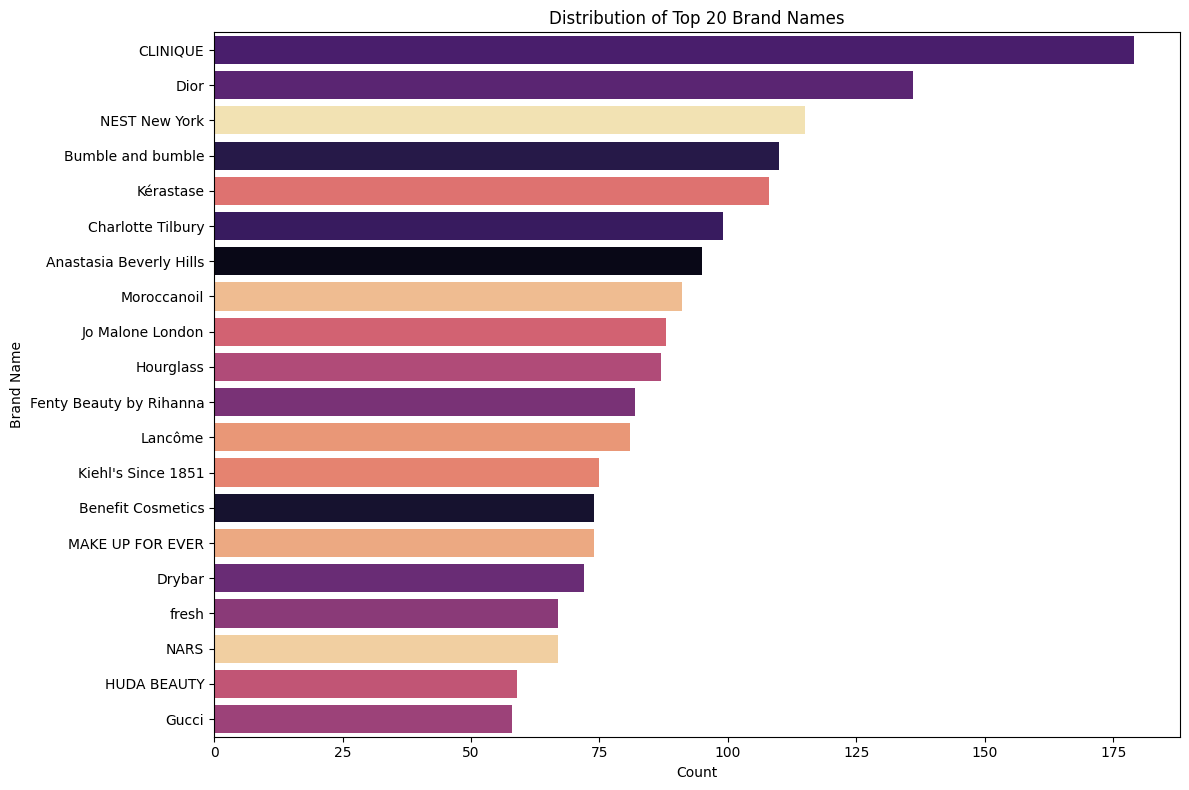

In [9]:
plt.figure(figsize=(12, 8)) # Increased height to accommodate more brands

# 1. We sort by value counts so the biggest brands are at the top
# 2. We take the top 15 or 20 brands so the chart isn't 5 miles long
top_brands = df['brand_name'].value_counts().nlargest(20).index

sns.countplot(
    data=df[df['brand_name'].isin(top_brands)],
    y='brand_name',           # Switched to 'y' for horizontal bars
    order=top_brands,         # Ensures they are sorted from most to least
    hue='brand_name',
    palette='magma',
    legend=False
)

plt.title('Distribution of Top 20 Brand Names')
plt.xlabel('Count')
plt.ylabel('Brand Name')

plt.tight_layout()
plt.show()

VISUALIZE THE DISTRIBUTION OF CATEGORY

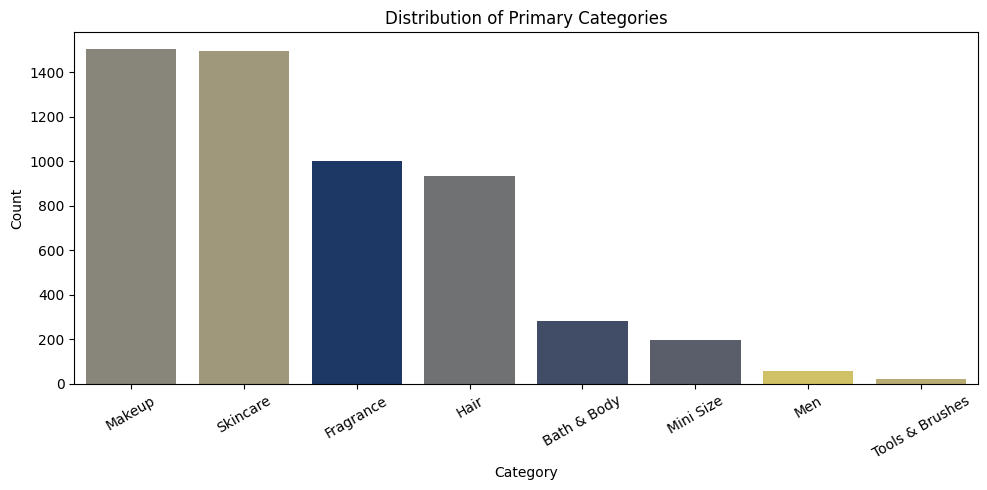

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='primary_category',
    order=df['primary_category'].value_counts().index,
    palette='cividis',
    hue='primary_category',
    legend=False
)

plt.title('Distribution of Primary Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30) # Small rotation is fine since there are only 8 categories
plt.tight_layout()
plt.show()

VISUALIZATION OF PRICE

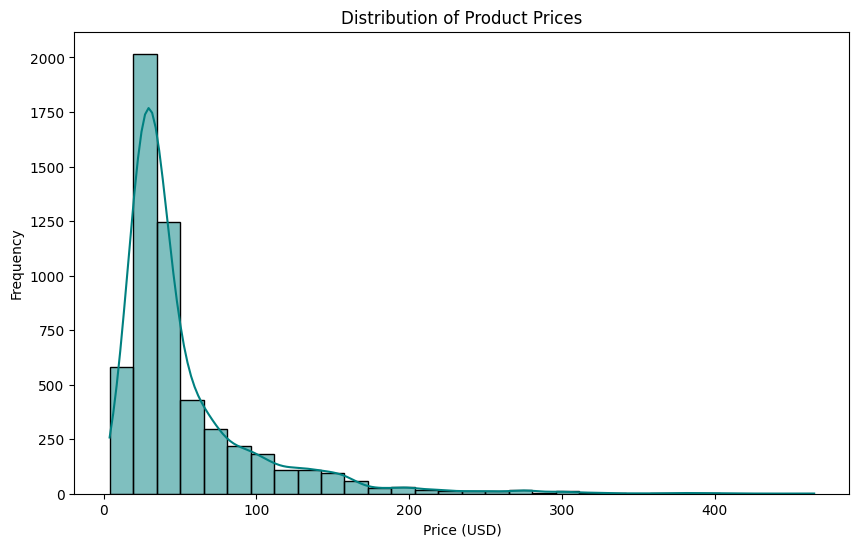

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_usd'], bins=30, kde=True, color='teal')

plt.title('Distribution of Product Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

VISUALIZE DISTRIBUTION OF PRODUCT RATING

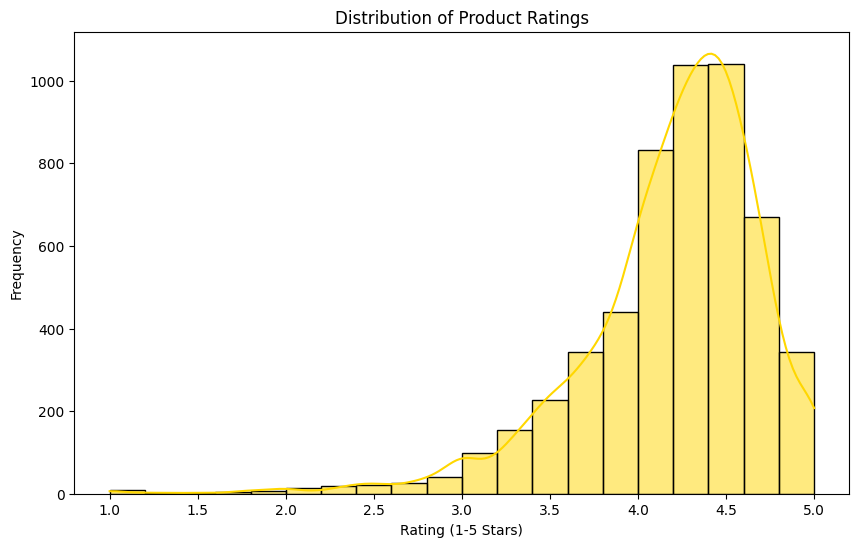

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'].dropna(), bins=20, kde=True, color='gold')

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Frequency')
plt.show()

MOST EXPENSIVE CATEGORY(FRAGRANCE OR MAKEUP)

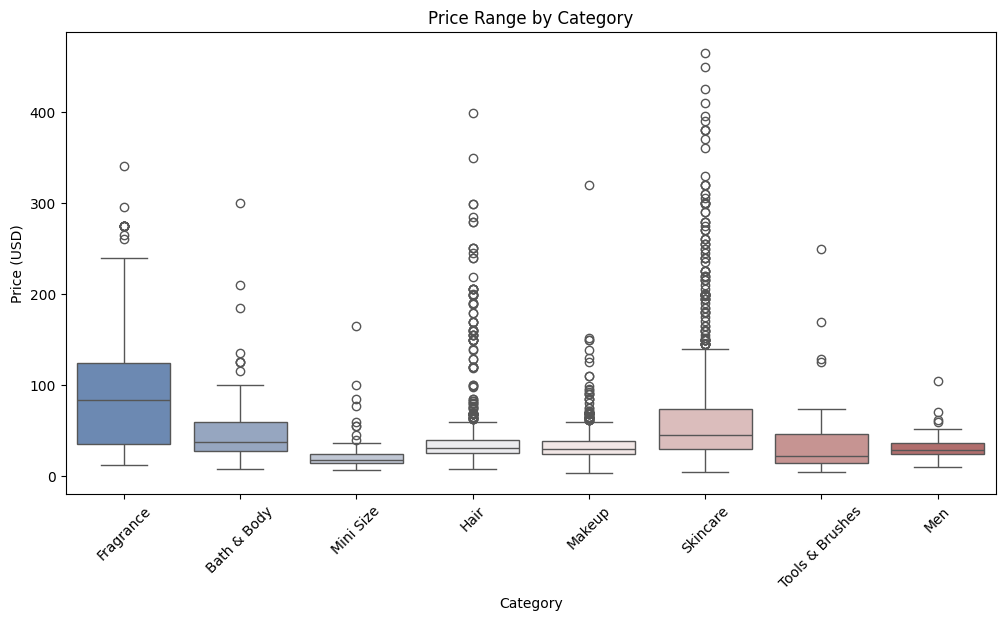

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='primary_category', y='price_usd', palette='vlag', hue='primary_category', legend=False)

plt.title('Price Range by Category')
plt.xlabel('Category')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.show()

TOP 10 MOST LOVED PRODUCTS

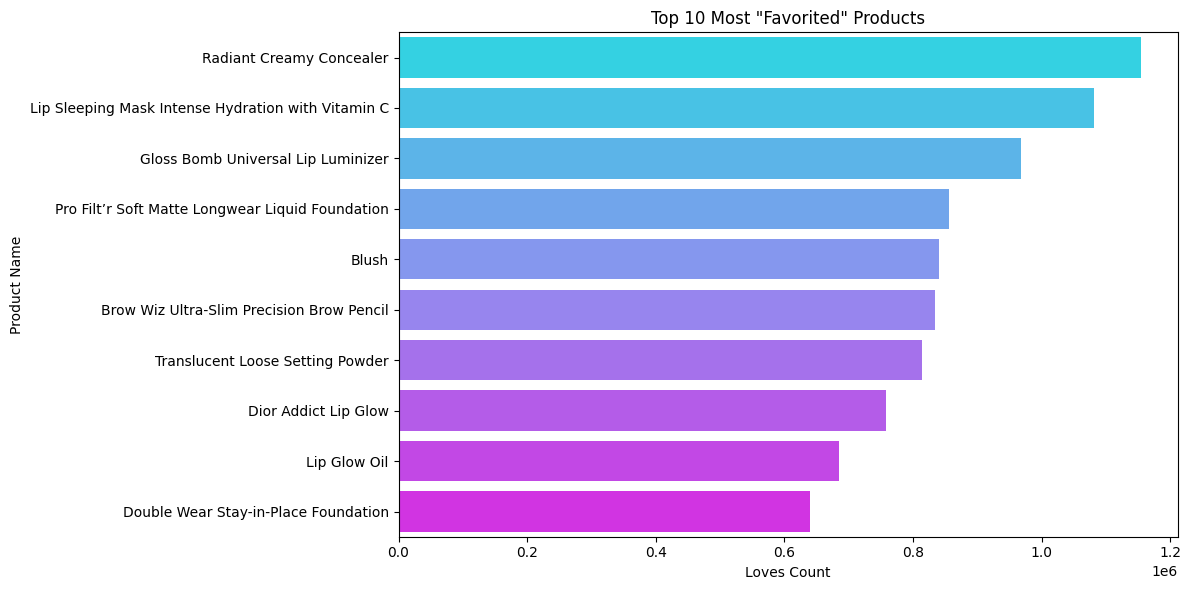

In [14]:
# Sort the dataframe by loves_count and take the top 10
top_loved_products = df.sort_values(by='loves_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_loved_products,
    x='loves_count',
    y='product_name',
    palette='cool',
    hue='product_name',
    legend=False
)

plt.title('Top 10 Most "Favorited" Products')
plt.xlabel('Loves Count')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

MOST POPULAR BRAND

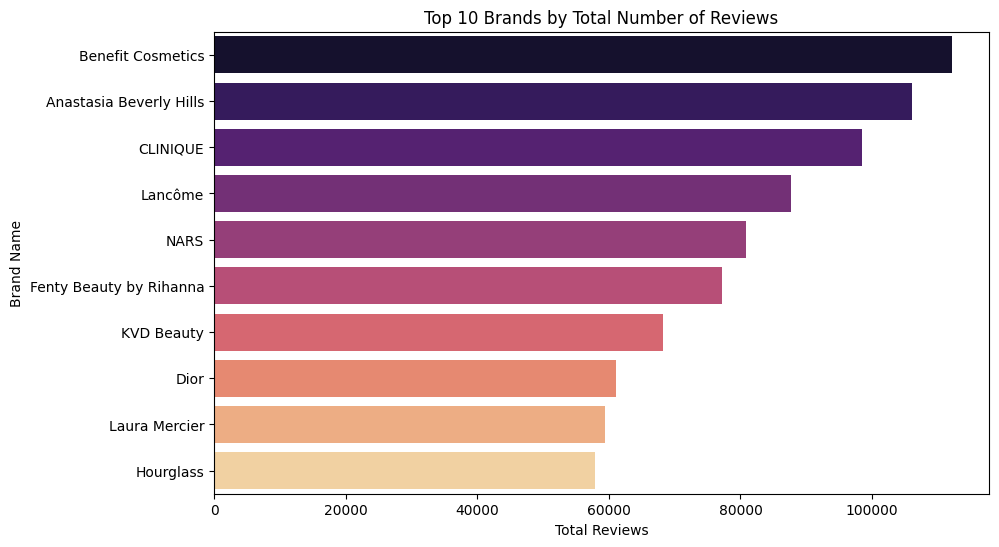

In [15]:
# Calculate total reviews per brand
top_reviewed = df.groupby('brand_name')['reviews'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_reviewed.values, y=top_reviewed.index, palette='magma', hue=top_reviewed.index, legend=False)

plt.title('Top 10 Brands by Total Number of Reviews')
plt.xlabel('Total Reviews')
plt.ylabel('Brand Name')
plt.show()